# Text Analysis + EDA

In [332]:
import pandas as pd
import ast
import string
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy 
import requests 
from bs4 import BeautifulSoup
import os 
import gc
import torch
import glob
import matplotlib.pyplot as plt

In [333]:
articles = pd.read_parquet("/home/jupyter-sc2641/Varshini_FP/5650-local-news-and-climate-change/data/cleaned_articles.parquet")
articles.head()

,id,publication_date,title,content,media_type,state,city,longitude,latitude,text_len,content_cleaned
0,fad5150893,2013-01-01,JFK watched Crimson Tide win Orange Bowl (This...,JFK watched Crimson Tide win Orange Bowl (This...,newspaper,Alabama,Birmingham,-86.801904,33.456412,972,jfk watched crimson tide win orange bowl day j...
1,aa619e60ff,2013-01-01,Communication is Key to Medication Adherence |...,Open or Close Search Form\nsearch\nChoose what...,newspaper,California,UC-San Francisco,-122.457400,37.763000,2958,open close search form search choose type sear...
2,4b6cdb61ea,2013-01-01,"February 2013 – Sonoma Sun | Sonoma, CA",Behind the dog show curtain\nPosted on Februar...,newspaper,California,Sonoma,-122.470580,38.277147,1322,behind dog show curtain posted dear dr forsyth...
3,475d97bec0,2013-01-01,Ventura County Star,Heartwarming moments defy chill at Rose Parade...,newspaper,California,Ventura,-119.301640,34.311203,3171,heartwarming moments defy chill rose parade ra...
4,80ffad1a1c,2013-01-01,‘Lunch lady’ Sandy Lenhardt has been serving S...,"PUBLISHED:\nJanuary 1, 2013 at 10:55 p.m.\nSur...",newspaper,Colorado,Longmont,-105.100330,40.171484,2327,published pm sure changes school lunch menus y...


In [334]:
articles["content_cleaned"].isna().sum()

np.int64(0)

In [335]:
articles = articles.dropna(subset = ["content_cleaned"]).reset_index(drop=True)

## Identify Articles on Climate Change

This could encompass articles on: 
- regular weather phenomena
- pollution
- extreme weather
- climate change
- global warming
- renewable/clean energy
- clean tech

and more.

Setting up to use a Hugging Face access token.

In [336]:
from dotenv import load_dotenv
import os
load_dotenv()
hf_token = os.environ["HF_TOKEN"]

Using Sentence BERT (SBERT, a.k.a Sentence Transformers) to do sentence-level text embeddings. SBERT is a module utilizing the BERT language model to compute embeddings from text (and other media) and is particularly useful for semantic search and semantic similarity. 

**NOTE:** Used Claude.AI to help with the below sections of code

In [337]:
from sentence_transformers import SentenceTransformer, util
from transformers import AutoModel, AutoTokenizer

# Set up the SentenceTransformer model
model = SentenceTransformer('all-MiniLM-L6-v2', token = hf_token)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [338]:
# Use GPU (esp. if needed to switch to Google Colab) if available, else use CPU
use_gpu = torch.cuda.is_available()

if use_gpu:
    model = model.to('cuda')
    
print(f"Using GPU: {use_gpu}")

Using GPU: False


In [339]:
# Queries
cc_queries = [
    "climate change and global warming",
    "rising temperatures and their environmental impact",
    "greenhouse gas emissions and climate crisis",
    "pollution and related health effects",
    "extreme weather events like fires, floods, and droughts",
    "renewable energy and clean tech",
]

# Set up embedding model for the queries
query_embeds = model.encode(cc_queries, convert_to_tensor = True)

Through batch processing, computing a similarity score for each article against the given climate change related queries above. 

The similarity score is calculated using Cosine Similarity, which measures the similarity between two vectors using the cosine of the angle between them. Chose to go with cosine similarity because the other options would either be more heavily influenced by the number of "characteristics" or are better suited for normalized embeddings.  

Sources consulted: 
- https://www.sbert.net/docs/sentence_transformer/usage/semantic_textual_similarity.html
- https://arxiv.org/html/2408.07706v1#S2
- https://medium.com/@arjunprakash027/understanding-cosine-similarity-a-key-concept-in-data-science-72a0fcc57599

In [340]:
# Set up the data to use as lists (content, IDs)
# Article content text
article_texts = articles["content_cleaned"].tolist()
# Article IDs
article_ids = articles["id"].tolist()

n = len(article_texts)

# Set up batch processing parameter
chunk_size = 10000

# Set up output directories for the multiple chunks from the batch processing
output_dir = "similarity_chunks"
os.makedirs(output_dir, exist_ok = True)

# Loop through the length of the articles by chunk_size 
for start in range(0, len(article_texts), chunk_size): 

    # Ensure last chunk doesn't go past the total number of articles
    end = min(start + chunk_size, len(article_texts))
    output_path = f"{output_dir}/{start}_{end}.npy"
    
    # Check if a file you're making already exists from a previous run
    if os.path.exists(output_path):
        print(f"Skipping {start}-{end}; already done.")
        continue

    # Create chunk 
    batch_texts = article_texts[start:end]

    # Encode the above chunk 
    batch_embeds = model.encode(batch_texts, convert_to_tensor = True, batch_size = 64, show_progress_bar = True)

    # Compute similarity score 
    batch_similarities = util.cos_sim(batch_embeds, query_embeds).max(dim = 1).values.cpu().numpy()

    # Save the results for this chunk
    np.save(output_path, batch_similarities)
    print(f"Finished & Saved {start}-{end}; {len(article_texts)}")

    # To prevent memory from slowly building up from chunk to chunk, clear
    # Remove reference to current chunk's embeddings & similarities
    del batch_embeds, batch_similarities
    # Utilize Python's garbage collector to free up memory immediately
    gc.collect()
    # Clear GPU memory, if used
    if use_gpu: 
        torch.cuda.empty_cache()
    

Skipping 0-10000; already done.
Skipping 10000-20000; already done.
Skipping 20000-30000; already done.
Skipping 30000-40000; already done.
Skipping 40000-50000; already done.
Skipping 50000-60000; already done.
Skipping 60000-70000; already done.
Skipping 70000-80000; already done.
Skipping 80000-90000; already done.
Skipping 90000-100000; already done.
Skipping 100000-110000; already done.
Skipping 110000-120000; already done.
Skipping 120000-130000; already done.
Skipping 130000-140000; already done.
Skipping 140000-150000; already done.
Skipping 150000-160000; already done.
Skipping 160000-170000; already done.
Skipping 170000-180000; already done.
Skipping 180000-190000; already done.
Skipping 190000-200000; already done.
Skipping 200000-210000; already done.
Skipping 210000-220000; already done.
Skipping 220000-230000; already done.
Skipping 230000-240000; already done.
Skipping 240000-250000; already done.
Skipping 250000-260000; already done.
Skipping 260000-270000; already don

In [341]:
# Find and sort each file in the chunk folders
chunk_files = sorted(glob.glob(f"{output_dir}/*.npy"), 
                     key = lambda x: int(os.path.basename(x).split("_")[0]))

# Pull together all the individual chunk arrays from above 
all_similarities = np.concatenate([np.load(f) for f in chunk_files])

# Safety check that the reassembled array has all the articles
assert len(all_similarities) == n, f"Mismatch: 'all_similarities' is only of length {len(all_similarities)}"

# Attach the array to the "articles" dataframe
articles["cc_similarity"] = all_similarities

# Save as parquet dataset so as to not repeat this process again
articles.to_parquet("articles_with_similarity.parquet")

print("Final results have been saved.")

Final results have been saved.


In [327]:
#articles = pd.read_parquet("articles_with_similarity.parquet")

Explore distribution of similarity scores to find the right threshold selection.

With cosine similarity, 1.0 means that the article text is perfectly related to the query text and 0.0 means that the article text and query text are unrelated. Negative values are rare but can indicate that the opposite meaning of the query text is being expressed in the article text.

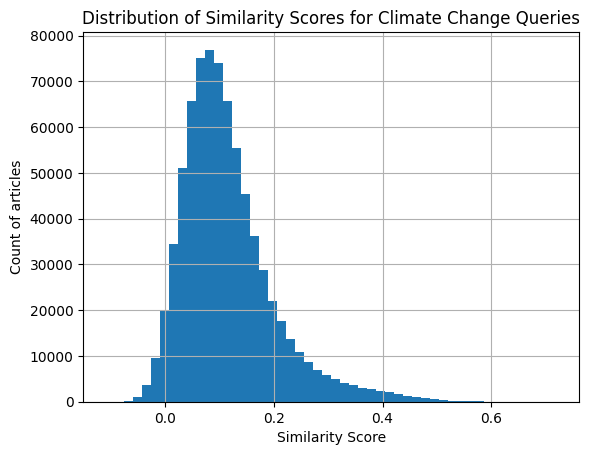

In [342]:
import matplotlib.pyplot as plt

articles["cc_similarity"].hist(bins = 50)
plt.xlabel("Similarity Score")
plt.ylabel("Count of articles")
plt.title("Distribution of Similarity Scores for Climate Change Queries")
plt.show()

In [343]:
for t in [-0.1, -0.05, 0.0, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5]:
    num = articles["cc_similarity"] >= t
    pct = num.mean() * 100
    print(f"Above threshold of {t}: {pct:.2f}% of articles ({num.sum()} articles)")

Above threshold of -0.1: 100.00% of articles (758515 articles)
Above threshold of -0.05: 99.90% of articles (757730 articles)
Above threshold of 0.0: 96.63% of articles (732973 articles)
Above threshold of 0.1: 49.10% of articles (372433 articles)
Above threshold of 0.15: 25.65% of articles (194570 articles)
Above threshold of 0.2: 13.19% of articles (100016 articles)
Above threshold of 0.25: 7.15% of articles (54252 articles)
Above threshold of 0.3: 4.11% of articles (31190 articles)
Above threshold of 0.35: 2.35% of articles (17833 articles)
Above threshold of 0.4: 1.20% of articles (9135 articles)
Above threshold of 0.5: 0.15% of articles (1112 articles)


From the above, we observe:
- Most of the articles have a similarity score between 0.0 and 0.2
- The right tail shows that there are some articles that do express a strong similarity score, but it is less than 10% of the articles
- Some outliers in the negative axis

Let's try another way to do this. 

Using an LLM to look at a sample of the articles and label whether the article is related to the query text or not. For this use case, Claude (Anthropic) is being used.

In [344]:
import anthropic

load_dotenv("anthropic_api_key.env")
anthropic_api_key = os.getenv("ANTHROPIC_API_KEY")

client = anthropic.Anthropic(api_key = anthropic_api_key)

In [345]:
def article_cc_relation(text, word_count_threshold):
    '''
    Function to use Claude Sonnet 5 (LLM) to read a given text and determine if it is related to climate change topics laid out in cc_queries above

    Input: 
    text = Body of text for LLM to review
    word_count_threshold = Threshold for number of words from given text for LLM to review
    
    '''
    # Select only the words in the given text that are under the given threshold for word count
    excerpt = " ".join(text.split()[:word_count_threshold])

    # Provide a concise prompt 
    prompt = f"""Is this news article primarily about climate change, global warming, or its environmental, health and policy impacts (including extreme weather events, renewable energy, clean tech, greenhouse gases, pollution, etc. when clearly related to climate change)?

    Respond with only one word: YES or NO.

    Article: {excerpt}
    
    """

    # Feed prompt and recieve answer to LLM
    response = client.messages.create(model = "claude-sonnet-5", max_tokens = 5, messages = [{"role": "user", "content": prompt}])

    # Account for articles that may flag up an API refusal due to category = "bio" (mark them as NaN instead of trying to force a label
    if response.stop_reason == "refusal":
        print(f"Refused (category: {response.stop_details.category if response.stop_details else "unknown"})")
        return None 

    # Account for potential empty responses from LLM
    if not response.content:
        print("Empty response recieved:", response)
        return None
        
    # Store answer from LLM
    answer = response.content[0].text.strip().upper()

    # Return as binary values 1/0
    return 1 if "YES" in answer else 0

Now, separating a validation sample from the dataset in order to test thresholds for the main SBERT sentence-level retrieval process.


In [346]:
np.random.seed(33)

articles["similarity_bin"] = pd.cut(articles["cc_similarity"], bins=10)

# art_sample = (articles.groupby("similarity_bin", group_keys = False)
#     .apply(lambda x: x.sample(min(len(x), 15), random_state = 42))
#     .reset_index(drop = True))

# Stratified sample across the "articles" dataset to get the best variety of rows 
def stratified_sample(bin, pct = 0.005, min_n = 10, max_n = 40):
    '''
    Function to pull an adaptive, stratified sample from a dataset based on the number of values in each bin
    
    '''

    n = len(bin)
    target = int(n * pct)
    target = max(min_n, min(target, max_n))
    target = min(target, n)
    
    return bin.sample(target, random_state = 33)

art_sample = (articles.groupby("similarity_bin", group_keys=False, observed=True)
    .apply(stratified_sample)
    .reset_index(drop = True))

# Reattach bin labels since the above will give key error
art_sample["similarity_bin"] = pd.cut(art_sample["cc_similarity"], 
                                      bins = [interval.left for interval in articles["similarity_bin"].cat.categories] + 
                                      [articles["similarity_bin"].cat.categories[-1].right])

print(f"Length of chosen sample from 'articles': {len(art_sample)}")
display(art_sample.groupby("similarity_bin", observed = True).size())

Length of chosen sample from 'articles': 295


similarity_bin
(-0.111, -0.0271]    25
(-0.0271, 0.056]     40
(0.056, 0.139]       40
(0.139, 0.222]       40
(0.222, 0.305]       40
(0.305, 0.388]       39
(0.388, 0.471]       41
(0.471, 0.555]       10
(0.555, 0.638]       10
(0.638, 0.721]       10
dtype: int64

In [347]:
display(articles["similarity_bin"].value_counts())

similarity_bin
(0.056, 0.139]       347315
(-0.0271, 0.056]     180619
(0.139, 0.222]       150104
(0.222, 0.305]        46042
(0.305, 0.388]        18508
(0.388, 0.471]         8591
(-0.111, -0.0271]      5033
(0.471, 0.555]         2082
(0.555, 0.638]          210
(0.638, 0.721]           13
Name: count, dtype: int64

In [348]:
# New column for LLM-provided label 
import time
from tqdm import tqdm

art_sample["cc_label"] = None

for idx, row in tqdm(art_sample.iterrows(), total = len(art_sample)):
    # Pass the sample article through the function set up above and assign answer value to the new col
    try: 
        label = article_cc_relation(row["content_cleaned"], word_count_threshold = 400)
        art_sample.loc[idx, "cc_label"] = label

    except Exception as e:
        print(f"Error in {idx}: {e}")
        # Set up "back off" time on rate limits/errors
        time.sleep(5)
    # Set up steady pacing so as to not overload    
    time.sleep(10)

print(f"{art_sample["cc_label"].isna().sum()} rows returned None due to API refusal or error.")

 20%|██        | 60/295 [12:13<49:19, 12.59s/it] 

Refused (category: bio)


 31%|███       | 91/295 [18:32<40:46, 11.99s/it]

Refused (category: bio)


 34%|███▍      | 100/295 [20:19<38:39, 11.90s/it]

...

Refused (category: bio)


 95%|█████████▌| 281/295 [56:47<02:51, 12.27s/it]

Refused (category: bio)


100%|██████████| 295/295 [59:37<00:00, 12.13s/it]

8 rows returned None due to API refusal or error.


In [357]:
art_sample["cc_label"].value_counts(dropna = False)

cc_label
0       261
1        26
None      8
Name: count, dtype: int64

In [353]:
# Manually label the 8 articles not identified by the LLM due to the safety wall
art_sample[art_sample["cc_label"].isna()]

,id,publication_date,title,content,media_type,state,city,longitude,latitude,text_len,content_cleaned,cc_similarity,similarity_bin,cc_label
60,225b93df13,2021-05-11,Frederick man gets 11 years for baseball bat a...,Save\nA Frederick man will serve 11 years in p...,newspaper,Maryland,Frederick,-77.389020,39.423344,1472,save frederick man serve years prison pleading...,0.052694,"(-0.0271, 0.056]",None
91,a154ea56ab,2017-07-11,Seguin’s Camacho wins big at Tattoo Show | New...,Seguin’s Camacho wins big at Tattoo Show\nVale...,newspaper,Texas,Seguin,-97.962830,29.564780,1828,seguin’s camacho wins big tattoo show valerie ...,0.071373,"(0.056, 0.139]",None
100,7a639bf79b,2015-09-23,Glynn Academy Players kick off a new season | ...,Joshua Sinyard is in his first year as the new...,newspaper,Georgia,Brunswick,-81.492130,31.166786,1530,joshua sinyard first year new drama teacher gl...,0.065688,"(0.056, 0.139]",None
170,7635ddc2e2,2017-02-20,Tamarack Sno-Flyers host 28th annual Vintage R...,Save\nThe lack of snow didn’t deter vintage sl...,newspaper,Minnesota,Aitkin,-93.664580,46.507241,1117,save lack snow didn’t deter vintage sled enthu...,0.254935,"(0.222, 0.305]",None
192,2830a78479,2018-11-22,City Mission works double duty on cold Thanksg...,City Mission works double duty on cold Thanksg...,newspaper,New York,Schenectady,-74.058015,42.833261,2774,city mission works double duty cold thanksgivi...,0.355296,"(0.305, 0.388]",None
224,03d2cc65b9,2013-07-29,Newport: Enviromentalists Stage Mock Oil Spill...,Save\nNEWPORT -- Six environmentally conscious...,newspaper,Vermont,Saint Johnsbury,-72.009960,44.412413,989,save newport six environmentally conscious stu...,0.328659,"(0.305, 0.388]",None
249,e5c0759744,2016-06-21,Harrowing stories abound from Lawton's latest ...,Email\nHarrowing stories abound from Lawton's ...,newspaper,Oklahoma,Lawton,-98.394140,34.608348,1658,email harrowing stories abound lawtons latest ...,0.456966,"(0.388, 0.471]",None
281,62ca2663c6,2018-09-12,County assesses damage from flooding | News | ...,Save\nRain that fell almost continually for se...,newspaper,Pennsylvania,Indiana,-79.161460,40.626307,2727,save rain fell almost continually several days...,0.577993,"(0.555, 0.638]",None


In [365]:
art_sample.loc[60, "cc_label"] = 0
art_sample.loc[91, "cc_label"] = 0
art_sample.loc[100, "cc_label"] = 0
art_sample.loc[170, "cc_label"] = 1
art_sample.loc[192, "cc_label"] = 1
art_sample.loc[224, "cc_label"] = 1
art_sample.loc[249, "cc_label"] = 1
art_sample.loc[281, "cc_label"] = 1

In [366]:
art_sample["similarity_bin"] = art_sample["similarity_bin"].astype(str)
art_sample.to_parquet("articles_sample_llm_labeled.parquet")

In [367]:
art_sample = pd.read_parquet("articles_sample_llm_labeled.parquet")

In [368]:
print(art_sample["cc_label"].unique())
print(art_sample["cc_label"].dtype)

[0 1]
int64


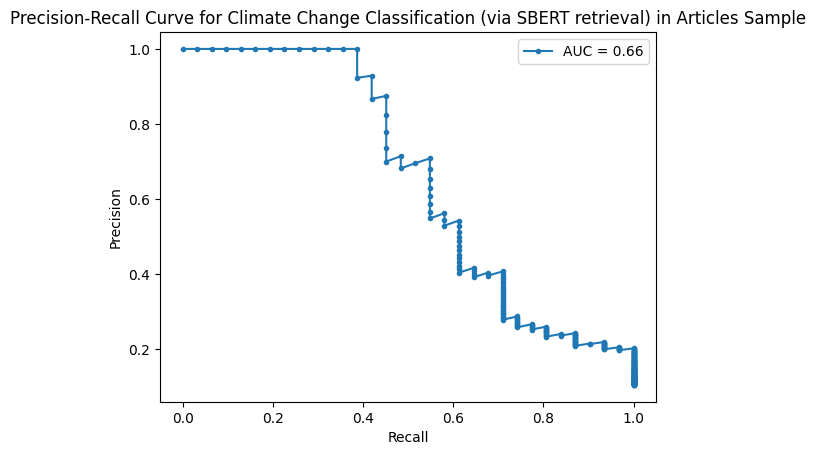

In [369]:
# Precision & Recall across thresholds
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, auc

y_true = art_sample["cc_label"].dropna().astype(int)
y_scores = art_sample.loc[y_true.index, "cc_similarity"]

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
auc_score = auc(recall, precision)

# Plot Precision-Recall Curve
plt.plot(recall, precision, marker = '.', label = f"AUC = {auc_score:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Climate Change Classification (via SBERT retrieval) in Articles Sample")
plt.legend()
plt.show()

From the above, test some specific thresholds. Using the following metrics to gauge best thresholds:
- Precision: Number of +ve predictions that are correct (TP / (TP + FP))
- Recall: Number of actual +ve cases that were correctly predicted as +ve (TP / (TP + FN))
- F1: Harmonic mean of Precision and Recall (2 * (Precision * Recall)/(Precision + Recall))

In [370]:
# Select and test some thresholds specifically

test_thresh = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5]

for thresh in test_thresh:
    preds = (y_scores >= thresh).astype(int)
    
    # Precision
    prec = precision_score(y_true, preds, zero_division = 0)
    # Recall
    rec = recall_score(y_true, preds, zero_division = 0)
    # F1
    f1 = f1_score(y_true, preds, zero_division = 0)
    
    print(f"For threshold of {thresh}: \nPrecision = {prec:.3f} \nRecall = {rec:.3f} \nF1 = {f1:.3f}\n")


For threshold of 0.1: 
Precision = 0.148 
Recall = 1.000 
F1 = 0.258

For threshold of 0.15: 
Precision = 0.169 
Recall = 1.000 
F1 = 0.290

For threshold of 0.2: 
Precision = 0.196 
Recall = 1.000 
F1 = 0.328

For threshold of 0.25: 
Precision = 0.218 
Recall = 0.935 
F1 = 0.354

For threshold of 0.3: 
Precision = 0.243 
Recall = 0.871 
F1 = 0.380

For threshold of 0.35: 
Precision = 0.277 
Recall = 0.742 
F1 = 0.404

For threshold of 0.4: 
Precision = 0.349 
Recall = 0.710 
F1 = 0.468

For threshold of 0.5: 
Precision = 0.607 
Recall = 0.548 
F1 = 0.576



Based on the above, let's find the best threshold: 

In [371]:
f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Best threshold by F1: {best_threshold}")

Best threshold by F1: 0.5159997344017029


But instead of blindly taking this F1 Score and moving forward, let's consider the number of articles at each threshold.

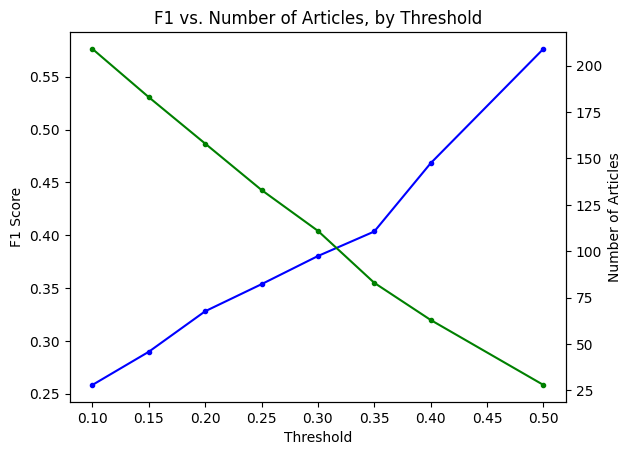

In [372]:
# Plot F1 Score and Number of Articles within the threshold bounds

art_counts = [(art_sample["cc_similarity"] >= t).sum() for t in test_thresh]

f1_thresh = []

#preds_thresh= art_sample["cc_label"]

for t in test_thresh:
    preds = (y_scores >= t).astype(int)
    f1_thresh.append(f1_score(y_true, preds, zero_division = 0))

fig, ax1 = plt.subplots()
ax1.plot(test_thresh, f1_thresh, color = "blue", marker = ".")
ax1.set_xlabel("Threshold")
ax1.set_ylabel("F1 Score")


ax2 = ax1.twinx()
ax2.plot(test_thresh, art_counts, color = "green", marker = ".")
ax2.set_ylabel("Number of Articles")

plt.title("F1 vs. Number of Articles, by Threshold")
plt.show()

In [463]:
# Create a "wave" column to identify the two survey waves in the articles dataset
articles["wave"] = np.select(
    condlist=[
        (articles["publication_date"] >= pd.Timestamp("2013-01-01")) & 
        (articles["publication_date"] < pd.Timestamp("2018-11-14")),
        
        (articles["publication_date"] >= pd.Timestamp("2018-11-14")) & 
        (articles["publication_date"] < pd.Timestamp("2023-04-13")),
    ],
    choicelist=[1, 2],
    default=np.nan  
)

In [464]:
articles["wave"].value_counts()

wave
2.0    380778
1.0    377739
Name: count, dtype: int64

In [374]:
# State-Wave Analysis

for t in test_thresh: 
    subset = articles[articles["cc_similarity"] >= t]
    counts_per_state_wave = subset.groupby(["state", "wave"]).size()
    print(f"Threshold {t}: total = {len(subset)}, "
          f"min per state/wave={counts_per_state_wave.min()}, "
          f"median={counts_per_state_wave.median()}"
         )

Threshold 0.1: total = 372433, min per state/wave=382, median=3088.5
Threshold 0.15: total = 194570, min per state/wave=219, median=1633.5
Threshold 0.2: total = 100016, min per state/wave=121, median=848.5
Threshold 0.25: total = 54252, min per state/wave=53, median=472.0
Threshold 0.3: total = 31190, min per state/wave=27, median=281.5
Threshold 0.35: total = 17833, min per state/wave=11, median=157.5
Threshold 0.4: total = 9135, min per state/wave=4, median=82.0
Threshold 0.5: total = 1112, min per state/wave=1, median=9.0


Choosing <b> Threshold = 0.25 </b>. Apply this to the main "articles" dataset.

In [433]:
cc_articles = articles[articles["cc_similarity"] >= 0.25]

In [434]:
display(len(articles))
display(len(cc_articles))

758517

54252

## Sentiment Analysis

Using a fine-tuned language model that is specifically built for, according to the website, "classifying climate-related paragraphs into the climate-related sentiment classes opportunity, neutral, or risk": Climate BERT(https://huggingface.co/climatebert/distilroberta-base-climate-sentiment). 

The assigned "label" for each article is one of the three following options: a negative <b>Risk</b>, a positive <b>Opportunity</b>, and <b>Neutral</b>. A confidence "score" is also assigned to display the softmax probability of the text belonging to the assigned label. 1.0 is very confident and 0.33 is unsure between the three labels. Note that the three labels do not indicate tone of the article but rather the framing of the article.

In [435]:
from transformers import pipeline

climate_sentiment_pipe = pipeline("text-classification", model = "climatebert/distilroberta-base-climate-sentiment", token = hf_token)

def climate_sentiment(text, max_words):
    excerpt = " ".join(text.split()[:max_words])
    result = climate_sentiment_pipe(excerpt, truncation = True)[0]
    return result["label"], result["score"]
    
# Set up the data to use as lists (content, IDs)
# Article content text
cc_article_texts = cc_articles["content_cleaned"].tolist()
# Article IDs
cc_article_ids = cc_articles["id"].tolist()

n = len(cc_article_texts)

# Set up batch processing parameter
cc_chunk_size = 2000

# Set up output directories for the multiple chunks from the batch processing
cc_output_dir = "sentiment_chunks"
os.makedirs(cc_output_dir, exist_ok = True)

for start in range(0, n, cc_chunk_size):
    end = min(start + cc_chunk_size, n)
    out_path = f"{cc_output_dir}/sent_{start}_{end}.npy"

    if os.path.exists(out_path):
        print(f"Skipping {start}-{end}; already done.")
        continue

    cc_batch_texts = [" ".join(t.split()[:300]) for t in cc_article_texts[start:end]]
    results = climate_sentiment_pipe(cc_batch_texts, truncation = True, batch_size = 32)
    
    sentiment_labels = [r["label"] for r in results]
    sentiment_scores = [r["score"] for r in results]

    np.save(out_path, np.array(list(zip(sentiment_labels, sentiment_scores))))
    print(f"Finished {start}-{end}")

    del results, sentiment_labels, sentiment_scores
    gc.collect()

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Skipping 0-2000; already done.
Skipping 2000-4000; already done.
Skipping 4000-6000; already done.
Skipping 6000-8000; already done.
Skipping 8000-10000; already done.
Skipping 10000-12000; already done.
Skipping 12000-14000; already done.
Skipping 14000-16000; already done.
Skipping 16000-18000; already done.
Skipping 18000-20000; already done.
Skipping 20000-22000; already done.
Skipping 22000-24000; already done.
Skipping 24000-26000; already done.
Skipping 26000-28000; already done.
Skipping 28000-30000; already done.
Skipping 30000-32000; already done.
Skipping 32000-34000; already done.
Skipping 34000-36000; already done.
Skipping 36000-38000; already done.
Skipping 38000-40000; already done.
Skipping 40000-42000; already done.
Skipping 42000-44000; already done.
Skipping 44000-46000; already done.
Skipping 46000-48000; already done.
Skipping 48000-50000; already done.
Skipping 50000-52000; already done.
Skipping 52000-54000; already done.
Skipping 54000-54252; already done.


In [436]:
cc_chunk_files = sorted(glob.glob(f"{cc_output_dir}/sent_*.npy"),
                        key = lambda x: int(os.path.basename(x).split("_")[1]))

all_cc_results = np.concatenate([np.load(f, allow_pickle = True) for f in cc_chunk_files])

assert len(all_cc_results) == n, f"Mismatch: 'all_cc_results' is only of length {len(all_cc_results)} out of total {n}"

cc_articles["sentiment_label"] = all_cc_results[:, 0]
cc_articles["sentiment_score"] = all_cc_results[:, 1].astype(float)

cc_articles.head()

,id,publication_date,title,content,media_type,state,city,longitude,latitude,text_len,content_cleaned,cc_similarity,similarity_bin,wave,sentiment_label,sentiment_score
6,c595339966,2013-01-01,Lyngbya clean-up crew discovers spring vent | ...,Lyngbya clean-up crew discovers spring vent\nV...,newspaper,Florida,Crystal River,-82.572703,28.867027,1542,lyngbya cleanup crew discovers spring vent vol...,0.273747,"(0.222, 0.305]",wave 2023,neutral,0.473710
18,1f7497a6f9,2013-01-01,Public fireworks displays continue through Jul...,©2007 The Osage County Herald \n ...,newspaper,Kansas,Osage City,-95.831320,38.611619,688,chronicle faimon publications webmaster rosie ...,0.316677,"(0.305, 0.388]",wave 2023,neutral,0.451371
36,324b2d6702,2013-01-01,Grave Danger: 9/11 Families Fight Plan to Put ...,Grave Danger: 9/11 Families Fight Plan to Put ...,newspaper,New York,New York,-73.996530,40.750742,3579,grave danger families fight plan put remains s...,0.334044,"(0.305, 0.388]",wave 2023,risk,0.903061
55,fa5ac9c025,2013-01-01,Tornado top story of 2012 | Local News | cross...,Newsletter\nClose\nAn ominous sky remained abo...,newspaper,Tennessee,Crossville,-85.059260,35.929314,12279,newsletter close ominous sky remained minutes ...,0.419437,"(0.388, 0.471]",wave 2023,risk,0.818218
69,7ff2e46896,2013-01-01,"Brad Barton, Chief Meteorologist, WBAP Morning...","Brad Barton, Chief Meteorologist, WBAP Morning...",radio,Texas,Dallas,-96.799410,32.787629,87,brad barton chief meteorologist wbap morning n...,0.300255,"(0.222, 0.305]",wave 2023,neutral,0.515923


In [437]:
cc_articles.drop(columns=["similarity_bin"]).to_parquet("cc_articles_with_sentiment.parquet")

In [438]:
cc_articles.drop(columns = ["similarity_bin"], inplace = True)

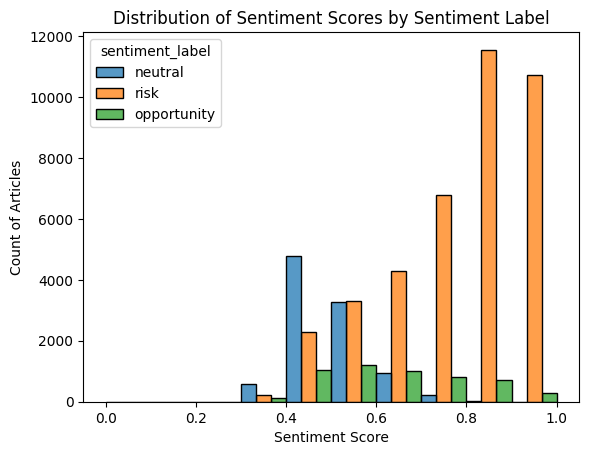

In [439]:
# Plot the sentiment_labels and sentiment_scores

fig, ax = plt.subplots()
sns.histplot(
    data = cc_articles, x = "sentiment_score", hue = "sentiment_label", multiple = "dodge",
    bins = np.linspace(0,1,11), ax = ax
)
plt.xlabel("Sentiment Score")
plt.ylabel("Count of Articles")
plt.title("Distribution of Sentiment Scores by Sentiment Label")
plt.show()

# EDA

## 1. Geographic Spread of Articles

### Frequency of Climate Change Articles by State

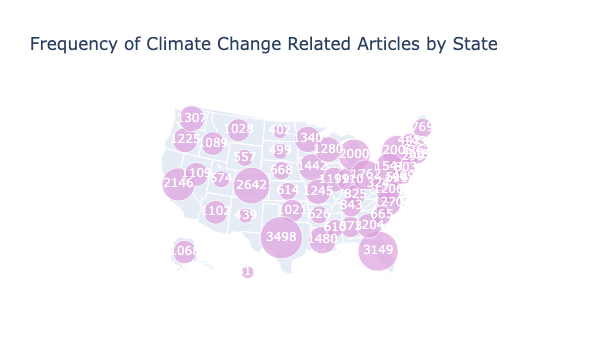

In [440]:
import plotly.express as px

df1 = cc_articles.groupby(["state"]).size().reset_index(name = "count")

fig = px.scatter_geo(df1,
    locations = "state",
    locationmode = "USA-states",
    size = "count",
    scope = "usa",
    color_discrete_sequence = ["#dda0dd"],
    hover_name = "state",
    size_max = 30,
    text = "count",
    title = f"Frequency of Climate Change Related Articles by State"
)
fig.update_traces(mode = "markers+text", textfont = dict(color = "white"))
fig.show()

### Spread of Climate Change Sentiment Labels for Articles by State

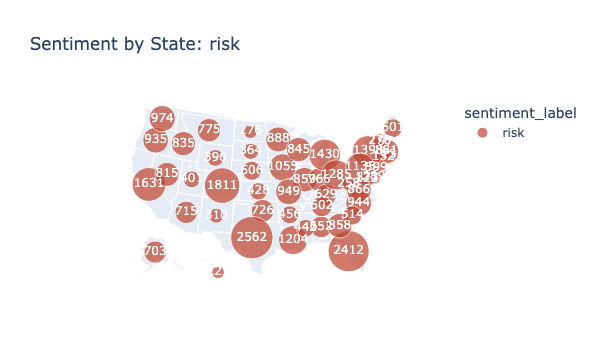

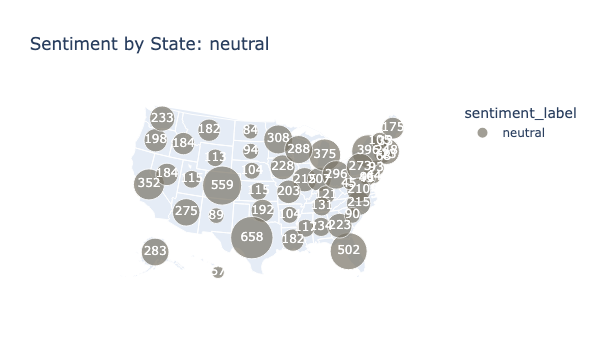

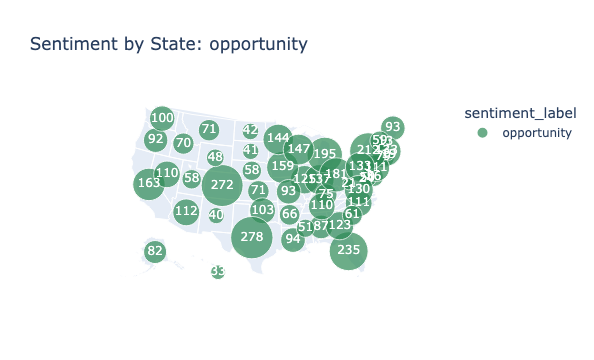

In [441]:
df2 = cc_articles.groupby(["state", "sentiment_label"]).size().reset_index(name = "count")

labels = ["risk", "neutral", "opportunity"]
colors = {"risk": "#C1432E", "neutral": "#7A7568", "opportunity": "#2E8B57"}

for label in labels:
    subset2 = df2[df2["sentiment_label"] == label]
    fig = px.scatter_geo(subset2,
        locations = "state",
        locationmode = "USA-states",
        size = "count",
        color = "sentiment_label",
        scope = "usa",
        color_discrete_sequence = [colors[label]],
        hover_name = "state",
        size_max = 30,
        text = "count",
        title = f"Sentiment by State: {label}"
    )
    fig.update_traces(mode = "markers+text", textfont = dict(color = "white"))
    fig.show()

## 2. Word Cloud

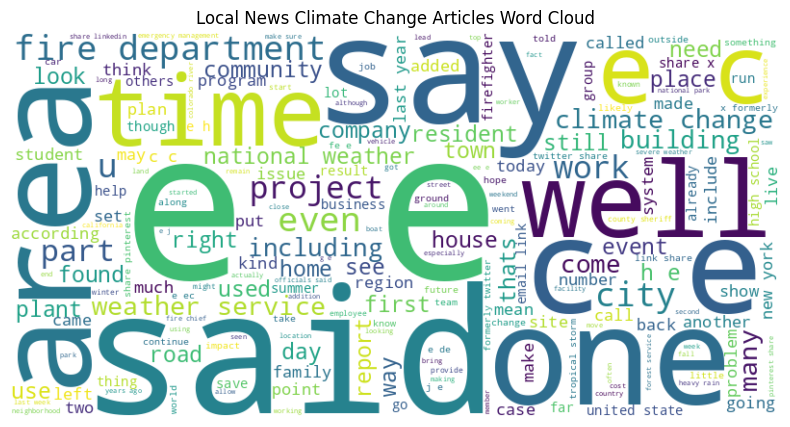

In [442]:
from wordcloud import WordCloud
import re

text = " ".join(cc_articles["content_cleaned"].astype(str).tolist())
text = re.sub(r'[^A-Za-z\s]', "", text)
text = text.lower()

wordcloud = WordCloud(width = 800, height = 400, background_color = 'white').generate(text)

plt.figure(figsize = (10, 5))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")  
plt.title("Local News Climate Change Articles Word Cloud")
plt.show()


## 3. Share of Coverage by City & State

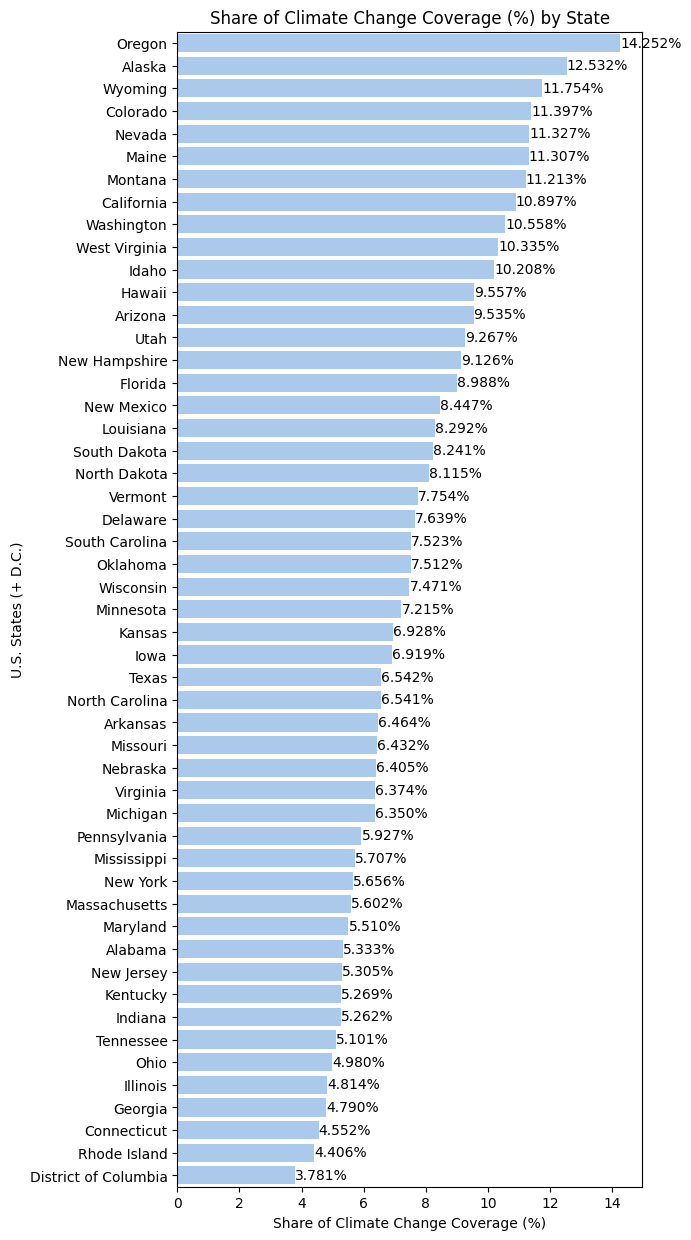

In [443]:
# Create a "share of coverage" metric
cc_counts = cc_articles.groupby("state").size().reset_index(name = "cc_count")
total_counts = articles.groupby("state").size().reset_index(name = "total_count")

coverage = cc_counts.merge(total_counts, on = "state")
coverage["coverage_share_by_state"] = coverage["cc_count"] / coverage["total_count"] * 100
coverage = coverage.sort_values("coverage_share_by_state", ascending = False)

# Horizontal Barplot
f, ax = plt.subplots(figsize = (6, 15))
sns.set_color_codes("pastel")
sns.barplot(x = "coverage_share_by_state", y = "state", data = coverage, color = "b",
           order = coverage.sort_values("coverage_share_by_state", ascending = False)["state"])
ax.bar_label(ax.containers[0], fmt = "%.3f%%")
plt.xlabel("Share of Climate Change Coverage (%)")
plt.ylabel("U.S. States (+ D.C.)")
plt.title("Share of Climate Change Coverage (%) by State")
plt.show()


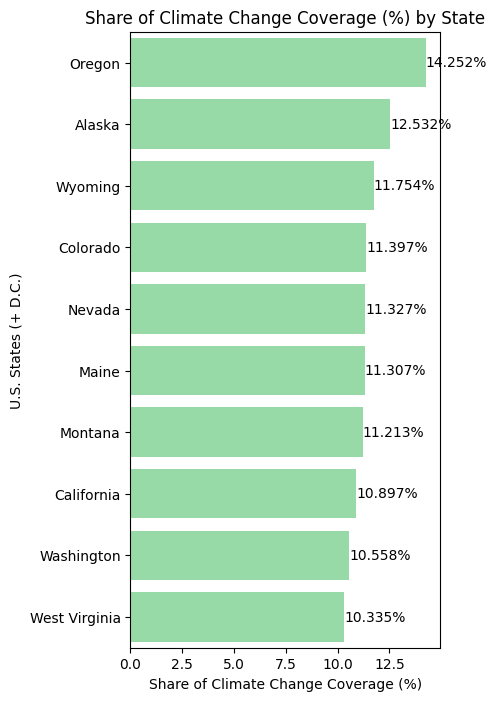

In [444]:
# Top 10 in the above Horizontal Barplot
top10 = coverage.head(10)

f, ax = plt.subplots(figsize = (4, 8))
sns.set_color_codes("pastel")
sns.barplot(x = "coverage_share_by_state", y = "state", data = top10, color = "g",
           order = top10.sort_values("coverage_share_by_state", ascending = False)["state"])
ax.bar_label(ax.containers[0], fmt = "%.3f%%")
plt.xlabel("Share of Climate Change Coverage (%)")
plt.ylabel("U.S. States (+ D.C.)")
plt.title("Share of Climate Change Coverage (%) by State")
plt.show()

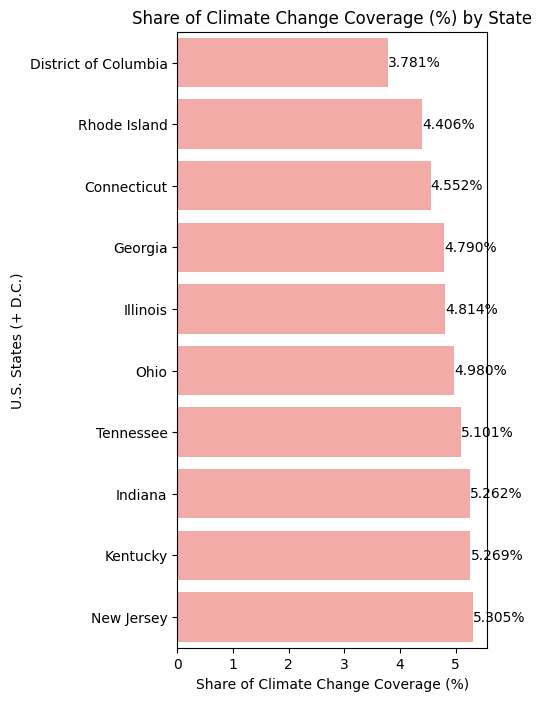

In [445]:
# Bottom 10 in the above Horizontal Barplot
bottom10 = coverage.tail(10)

f, ax = plt.subplots(figsize = (4, 8))
sns.set_color_codes("pastel")
sns.barplot(x = "coverage_share_by_state", y = "state", data = bottom10, color = "r",
           order = bottom10.sort_values("coverage_share_by_state", ascending = True)["state"])
ax.bar_label(ax.containers[0], fmt = "%.3f%%")
plt.xlabel("Share of Climate Change Coverage (%)")
plt.ylabel("U.S. States (+ D.C.)")
plt.title("Share of Climate Change Coverage (%) by State")
plt.show()

## Metrics

The goal of the project is to understand the effect of local news coverage of climate change on public opinion of climate change. This involves two main metrics: 

1. Frequency of Coverage (Volume & Share of Climate Change Articles)
2. Framing of Coverage (Sentiment Label)

In [454]:
# Create "wave" column that divides the the dataset according to the Survey dates
cc_articles["wave"] = np.select(
    condlist=[
        (cc_articles["publication_date"] >= pd.Timestamp("2013-01-01")) & 
        (cc_articles["publication_date"] < pd.Timestamp("2018-11-14")),
        
        (cc_articles["publication_date"] >= pd.Timestamp("2018-11-14")) & 
        (cc_articles["publication_date"] < pd.Timestamp("2023-04-13")),
    ],
    choicelist = [1, 2],
    default = np.nan  
)

cc_articles["wave"] = np.where(cc_articles["wave"] == 1.0, "wave 2018", "wave 2023")

In [455]:
cc_articles["wave"].value_counts()

wave
wave 2023    29642
wave 2018    24610
Name: count, dtype: int64

### Volume
Defined as the count of articles that are or related to Climate Change content by state by wave.

In [456]:
# Volume of Articles by State & Wave
#cc_articles["wave"] = np.where(cc_articles["wave"] == 1.0, "wave 2018", "wave 2023")
cc_volume_sw = cc_articles.groupby(["state", "wave"]).size().reset_index(name = "volume_by_state_wave")


In [457]:
cc_volume_sw.head()

,state,wave,volume_by_state_wave
0,Alabama,wave 2018,391
1,Alabama,wave 2023,482
2,Alaska,wave 2018,447
3,Alaska,wave 2023,621
4,Arizona,wave 2018,441


In [458]:
cc_volume_sw["wave"].value_counts()

wave
wave 2018    51
wave 2023    51
Name: count, dtype: int64

### Share of Coverage

Defined as the percentage of articles produced from a state that are about climate change, by state by wave.

In [468]:
# Total Count of Articles by State & Wave
articles1 = articles.copy()
articles1["wave"] = np.where(articles1["wave"] == 1.0, "wave 2018", "wave 2023")
total_volume_sw = articles1.groupby(["state", "wave"]).size().reset_index(name = "total_volume_by_state_wave")

# Share of Coverage by State & Wave
share_df = cc_volume_sw.merge(total_volume_sw, on = ["state", "wave"])
share_df["coverage_share"] = share_df["volume_by_state_wave"] / share_df["total_volume_by_state_wave"]


In [471]:
share_df.head()

,state,wave,volume_by_state_wave,total_volume_by_state_wave,coverage_share
0,Alabama,wave 2018,391,7970,0.049059
1,Alabama,wave 2023,482,8401,0.057374
2,Alaska,wave 2018,447,3806,0.117446
3,Alaska,wave 2023,621,4716,0.131679
4,Arizona,wave 2018,441,4847,0.090984


In [472]:
share_df["wave"].value_counts()

wave
wave 2018    51
wave 2023    51
Name: count, dtype: int64

In [470]:
articles1["wave"].value_counts()

wave
wave 2023    380778
wave 2018    377739
Name: count, dtype: int64

### Sentiment Label
Using the sentiment_label aggregated up to a state-level by wave. We're going to make this a continuous measure that 

In [482]:
cc_framing_sw = cc_articles.groupby(["state", "wave", "sentiment_label"]).size().reset_index(name = "count")

cc_framing_sw = cc_framing_sw.pivot_table(index = ["state", "wave"], 
                                          columns = "sentiment_label", 
                                          values = "count", 
                                          fill_value = 0).reset_index()

cc_framing_sw["total"] = cc_framing_sw[["risk", "neutral", "opportunity"]].sum(axis = 1)
                                          

In [484]:
# Share of each label's count of articles
cc_framing_sw["risk_share"] = cc_framing_sw["risk"] / cc_framing_sw["total"]
cc_framing_sw["opportunity_share"] = cc_framing_sw["opportunity"] / cc_framing_sw["total"]
cc_framing_sw["neutral_share"] = cc_framing_sw["neutral"] / cc_framing_sw["total"]


In [485]:
# A balance metric: 
cc_framing_sw["balance"] = (cc_framing_sw["opportunity"] - cc_framing_sw["risk"]) / cc_framing_sw["total"]


In [487]:
display(cc_framing_sw["balance"].max())
display(cc_framing_sw["balance"].min())


np.float64(-0.22151898734177214)

np.float64(-0.7748917748917749)

In [488]:
cc_framing_sw.columns.name = None
cc_framing_sw.head()

,state,wave,neutral,opportunity,risk,total,risk_share,opportunity_share,neutral_share,balance
0,Alabama,wave 2018,66.0,38.0,287.0,391.0,0.734015,0.097187,0.168798,-0.636829
1,Alabama,wave 2023,68.0,49.0,365.0,482.0,0.757261,0.101660,0.141079,-0.655602
2,Alaska,wave 2018,131.0,35.0,281.0,447.0,0.628635,0.078300,0.293065,-0.550336
3,Alaska,wave 2023,152.0,47.0,422.0,621.0,0.679549,0.075684,0.244767,-0.603865
4,Arizona,wave 2018,105.0,43.0,293.0,441.0,0.664399,0.097506,0.238095,-0.566893


In [486]:
cc_framing_sw["wave"].value_counts()

wave
wave 2018    51
wave 2023    51
Name: count, dtype: int64

In [489]:
len(cc_framing_sw)

102

In [490]:
# merge cc_volume_sw and cc_framing sw
cc_metrics1 = cc_volume_sw.merge(cc_framing_sw, on = ["state", "wave"], how = "inner")


In [492]:
# merge cc_metrics and share_df to get share_of_coverage metric
cc_metrics1 = cc_metrics1.merge(share_df, on = ["state", "wave"], how = "inner")
                              

In [493]:
cc_metrics1["wave"].value_counts()

wave
wave 2018    51
wave 2023    51
Name: count, dtype: int64

In [496]:
cc_metrics1.drop(columns = ["volume_by_state_wave_x"], inplace = True)
cc_metrics1 = cc_metrics1.rename(columns = {"volume_by_state_wave_y": "volume_by_state_wave"})


In [497]:
cc_metrics1.head()

,state,wave,neutral,opportunity,risk,total,risk_share,opportunity_share,neutral_share,balance,volume_by_state_wave,total_volume_by_state_wave,coverage_share
0,Alabama,wave 2018,66.0,38.0,287.0,391.0,0.734015,0.097187,0.168798,-0.636829,391,7970,0.049059
1,Alabama,wave 2023,68.0,49.0,365.0,482.0,0.757261,0.101660,0.141079,-0.655602,482,8401,0.057374
2,Alaska,wave 2018,131.0,35.0,281.0,447.0,0.628635,0.078300,0.293065,-0.550336,447,3806,0.117446
3,Alaska,wave 2023,152.0,47.0,422.0,621.0,0.679549,0.075684,0.244767,-0.603865,621,4716,0.131679
4,Arizona,wave 2018,105.0,43.0,293.0,441.0,0.664399,0.097506,0.238095,-0.566893,441,4847,0.090984


In [498]:
cc_metrics1["wave"].value_counts()

wave
wave 2018    51
wave 2023    51
Name: count, dtype: int64

# Save Dataset

In [499]:
cc_metrics1.to_parquet("cc_labels_and_share.parquet")